In [2]:
import pandas as pd
import os

# Load data
df = pd.read_csv("/home/sarmiento/MEDS/EDS-220/eds220-discussion-sections/data/Colorado River Basin Water Conflict Table.csv")

In [9]:
list(df)

['Event',
 'Search Source',
 'Newspaper',
 'Article Title',
 'Duplicate',
 'Report Date',
 'Report Year',
 'Event Date',
 'Event Day',
 'Event Month',
 'Event Year',
 'Conflict Present',
 'Crisis Present',
 'Basin',
 'HUC6',
 'HUC2',
 'Place',
 'County',
 'County FIPS',
 'State',
 'State FIPS',
 'Urban or Rural',
 'Issue Type',
 'Event Summary',
 'Stakeholders',
 'Intensity Value',
 'Comments',
 'Related Observation Themes',
 'Article Text Search - water quality',
 'Article Text Search - invasive species',
 'Article Text Search - conservation',
 'Article Text Search - drought',
 'Article Text Search - flood',
 'Article Text Search - ground water depletion',
 'Article Text Search - depletion',
 'Article Text Search - infrastructure',
 'Article Text Search - fish passage',
 'Article Text Search - instream water rights',
 'Article Text Search - water rights',
 'Article Text Search - intergovernmental',
 'Article Text Search - water transfers',
 'Article Text Search - navigation',
 'Articl

In [10]:
df.shape

(268, 48)

In [11]:
df.nunique()

Event                                           268
Search Source                                     6
Newspaper                                        45
Article Title                                   267
Duplicate                                         2
Report Date                                     235
Report Year                                      18
Event Date                                       52
Event Day                                        12
Event Month                                      12
Event Year                                       21
Conflict Present                                  2
Crisis Present                                    2
Basin                                            25
HUC6                                             22
HUC2                                              7
Place                                           135
County                                            3
County FIPS                                       3
State       

In [12]:
df.head()

,Event,Search Source,Newspaper,Article Title,Duplicate,Report Date,Report Year,Event Date,Event Day,Event Month,...,Article Text Search - water rights,Article Text Search - intergovernmental,Article Text Search - water transfers,Article Text Search - navigation,Article Text Search - fish,Article Text Search - invasive,Article Text Search - diversion,Article Text Search - water diversion,Article Text Search - instream,Article Text Search - aquatic
0,1,USGS1-50.docx,The Durango Herald (Colorado),Tribes assert water rights on Colorado River B...,False,7-Apr-22,2022.0,NaN,NaN,4.0,...,17,0,0,0,0,0,0,0,0,0
1,2,USGS1-50.docx,"Journal, The (Cortez, Dolores, Mancos, CO)",Native American tribes assert water rights on ...,False,7-Apr-22,2022.0,NaN,NaN,4.0,...,17,0,0,0,0,0,0,0,0,0
2,3,USGS1-50.docx,The Salt Lake Tribune,'Very positive change.' New Utah law will be a...,False,17-Mar-22,2022.0,NaN,NaN,3.0,...,12,0,0,0,1,0,0,0,12,1
3,4,USGS1-50.docx,Casa Grande Dispatch (AZ),Legislation would let an Arizona tribe lease C...,False,11-Dec-21,2021.0,NaN,NaN,12.0,...,6,0,0,0,0,0,0,0,0,0
4,5,USGS1-50.docx,The Aspen Times (Colorado),Historically excluded from Colorado River poli...,False,19-Dec-21,2021.0,NaN,NaN,11.0,...,18,0,0,0,0,0,0,0,0,0


In [3]:
df.isna().sum()

Event                                             0
Search Source                                     0
Newspaper                                         0
Article Title                                     0
Duplicate                                         1
Report Date                                       1
Report Year                                       3
Event Date                                       20
Event Day                                       250
Event Month                                      56
Event Year                                       11
Conflict Present                                 16
Crisis Present                                   14
Basin                                            18
HUC6                                            158
HUC2                                             18
Place                                            14
County                                          260
County FIPS                                     260
State       

In [6]:
df['Place'].value_counts()

Place
Entire Colorado River Basin                                              19
State of Arizona                                                         17
Colorado River Basin                                                     13
Great Salt Lake                                                          10
Arizona                                                                   6
                                                                         ..
Gila River Indian Reservation                                             1
Navajo Nation, Hopi Reservation                                           1
AZ, CO, NM, UT, Southern Ute Tribe, Ute Mountain tribe, Navajo Nation     1
Laughlin, AZ                                                              1
State of Arizona, State of California                                     1
Name: count, Length: 135, dtype: int64

In [7]:
df['State'].value_counts()

State
AZ                            66
CO                            34
UT                            27
NV                            10
CA                             7
NM                             6
AZ; CA                         4
AZ; UT                         3
AZ; CA; CO; NV; NM; UT; WY     3
AZ; NV                         2
NV; AZ                         2
CO; AZ                         2
CO; UT; WY; NM                 2
AZ; NM                         1
CA; NV; AZ                     1
WY; UT; CO                     1
UT; CO; WY                     1
CO; WY                         1
AZ; CA; NV                     1
UT; AZ                         1
AZ; CO; NM; UT                 1
OH; UT                         1
TX                             1
Name: count, dtype: int64

In [17]:
df['Conflict Present'].value_counts()

Conflict Present
Y    145
N    107
Name: count, dtype: int64

In [65]:
# CELL 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example series
s = pd.Series(['California; Nevada', 'Arizona', np.nan, 'Nevada; Utah'])
s

0    California; Nevada
1               Arizona
2                   NaN
3          Nevada; Utah
dtype: object

In [19]:
# CELL 2
# str accessor (doesn't do anything by itself)
s.str

In [39]:
# CELL 3
# Use str accessor with additional methods to perform string operations
s.str.split(';')

pandas.core.series.Series

In [28]:
# CELL 4
s.str.split('n').explode()

0         Califor
0      ia; Nevada
1           Arizo
1               a
2             NaN
3    Nevada; Utah
dtype: object

In [32]:
# Non-NA values in the State column
df.loc[df["State"].notna(),"State"]

0          CO
1          CO
2          UT
5          AZ
11     OH; UT
        ...  
263        CO
264        CO
265    AZ; CA
266        AZ
267        AZ
Name: State, Length: 178, dtype: object

In [77]:
ConYes = df.loc[df['Conflict Present'] == 'Y', 'State']
type(ConYes)

pandas.core.series.Series

In [56]:
ConYes.str.split(';')

0           [CO]
1           [CO]
4            NaN
5           [AZ]
7            NaN
         ...    
257         [AZ]
258         [UT]
260          NaN
262         [AZ]
265    [AZ,  CA]
Name: State, Length: 145, dtype: object

In [48]:
ConYesState

State
AZ                            32
UT                            20
CO                            15
NV                             6
NM                             5
AZ; CA                         3
AZ; CA; CO; NV; NM; UT; WY     2
NV; AZ                         2
AZ; UT                         2
CO; UT; WY; NM                 2
AZ; NV                         2
CA                             2
OH; UT                         1
UT; CO; WY                     1
AZ; NM                         1
WY; UT; CO                     1
CO; AZ                         1
Name: count, dtype: int64

In [ ]:
df["State"].str.split(';').explode()

In [ ]:
#THE REAL EXPLORATARY RANLGING

In [57]:
df.loc[df['Conflict Present'] == 'Y', 'State'].str.split(';').explode().unique()

array(['CO', nan, 'AZ', 'OH', ' UT', 'UT', 'CA', ' NV', ' WY', ' NM',
       ' CA', 'NV', ' AZ', ' CO', 'NM', 'WY'], dtype=object)

In [69]:
df.loc[df['Conflict Present'] == 'Y', 'State'].str.split(';').explode().str.strip().unique()

array(['CO', nan, 'AZ', 'OH', 'UT', 'CA', 'NV', 'WY', 'NM'], dtype=object)

In [78]:
the_data = (df.loc[df['Conflict Present'] == 'Y', 'State'].str.split(';').explode().str.strip().value_counts())
the_data
type(the_data)

pandas.core.series.Series

<Axes: xlabel='State'>

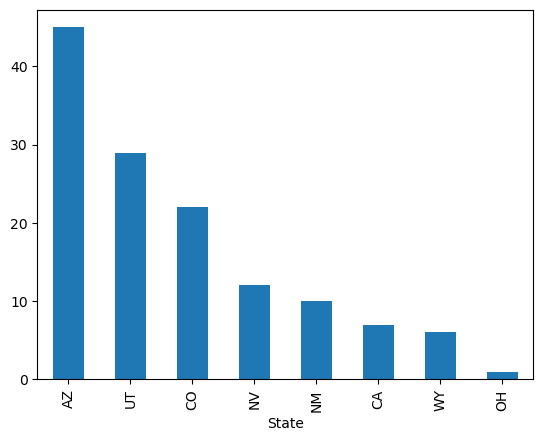

In [80]:
the_data.plot(kind = 'bar')